# Chen et al. 2026 — NWB dataset tutorial

This notebook demonstrates how to read and visualise data from the Chen et al. 2026
LRRK2 fiber-photometry dataset.
One session is used as an example: **subject 4007 (Anxa group, LRRK2-G2019S), recorded 2025-08-13**.

Contents:
1. NWBFile and subject metadata
2. Fiber photometry metadata (FiberPhotometryTable, devices, indicator)
3. Raw fiber photometry (full session and zoomed with stim)
4. CommandedVoltageSeries — LED switching square wave (data provenance, FP linkage)
5. Raw treadmill voltage (data provenance)
6. Processed fiber photometry — corrected traces and ΔF/F
7. ΔF/F aligned to a single stimulation onset
8. Treadmill behavior (velocity and acceleration)
9. Optogenetic epochs table — per-epoch power values and full-session power map
10. ABF Events — individual optogenetic pulses (OptoTTL)
11. Optogenetics metadata (ndx-optogenetics)
12. Peri-stimulus ΔF/F (PSTH) — grand average, per-power traces, single-trial heatmap

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pynwb import read_nwb

NWB_PATH = "/Users/weian/lrrk2_data/nwb-output/sub-4007-anxa-gs_ses-2025-08-13-0005.nwb"

nwb = read_nwb(NWB_PATH)
sub = nwb.subject

## 1. NWBFile and subject metadata

Top-level NWBFile fields (session description, institution, lab, experimenter) and
subject metadata (ID, species, strain, genotype) are stored directly on the NWBFile object.

In [2]:
print(f"Identifier:            {nwb.identifier}")
print(f"Session ID:            {nwb.session_id}")
print(f"Session start time:    {nwb.session_start_time}")
print(f"Session description:   {nwb.session_description}")
print(f"Experiment description: {nwb.experiment_description}")
print(f"Institution:           {nwb.institution}")
print(f"Lab:                   {nwb.lab}")
print(f"Experimenter(s):       {', '.join(nwb.experimenter)}")
print(f"Keywords:              {', '.join(nwb.keywords)}")
print()
print(f"Subject ID:            {sub.subject_id}")
print(f"Species:               {sub.species}")
print(f"Strain:                {sub.strain}")
print(f"Genotype:              {sub.genotype}")
print(f"Sex:                   {sub.sex}")
print(f"Date of birth:         {sub.date_of_birth}")
print(f"Description:           {sub.description}")

Identifier:            6a76d6a7-69fc-4b64-b5b1-85fb07ec6b1c
Session ID:            2025-08-13-0005
Session start time:    2025-08-13 16:24:04.075000-05:00
Session description:   Fiber photometry recording of GRAB-DA3m dopamine fluorescence in the dorsal lateral striatum (DLS) during optogenetic activation of Anxa1+ dopamine neuron cell bodies in SNc (ChRmine, 635 nm) in an awake head-fixed LRRK2-G2019S mouse on a treadmill. Data sources: fiber photometry (raw multiplexed fluorescence at 2 kHz), optogenetic stimulation TTL, and treadmill velocity.

Experiment description: In vivo fiber photometry of striatal dopamine release in awake, head-fixed mice expressing the dopamine sensor GRAB-DA3m. Two intersectional mouse lines targeting distinct dopamine neuron subtypes were studied: Anxa1-iCre mice (Anxa1+, vulnerable subtype) with fiber photometry in the dorsal lateral striatum (DLS), and Calb1-Cre mice (Calb1+, resilient subtype) with fiber photometry in the dorsal medial striatum (DMS). 

## 2. Fiber photometry metadata

Recording metadata (brain location, wavelengths, indicator, hardware) is stored via the
[ndx-fiber-photometry](https://github.com/catalystneuro/ndx-fiber-photometry) and
[ndx-ophys-devices](https://github.com/catalystneuro/ndx-ophys-devices) extensions.

In [3]:
fp_meta = nwb.lab_meta_data["fiber_photometry"]
fp_table = fp_meta.fiber_photometry_table

print(f"FP table rows: {len(fp_table.to_dataframe())}")
print(f"Recording location:       {fp_table['location'][0]}")
print(f"Excitation wavelength:    {fp_table['excitation_wavelength_in_nm'][0]} nm")
print(f"Emission wavelength:      {fp_table['emission_wavelength_in_nm'][0]} nm")

ind = fp_table["indicator"][0]
print(f"\nIndicator label:          {ind.label}")
print(f"Indicator description:    {ind.description}")

# Excitation source devices
es_signal = nwb.devices["signal_excitation_source"]
es_isos   = nwb.devices["isosbestic_excitation_source"]
print(f"\nSignal source (470 nm):   {es_signal.name}")
print(f"  model:                  {es_signal.model.name}  ({es_signal.model.manufacturer})")
print(f"  model number:           {es_signal.model.model_number}")
print(f"Isosbestic source (405 nm): {es_isos.name}")
print(f"  model:                  {es_isos.model.name}  ({es_isos.model.manufacturer})")
print(f"  model number:           {es_isos.model.model_number}")

# Optical fiber (Anxa group → DLS; Calb group → use 'optical_fiber_dms')
of_device = nwb.devices["optical_fiber_dls"]
of_model = of_device.model
fi = of_device.fiber_insertion
print(f"\nOptical fiber (DLS, fiber photometry):")
print(f"  model number:           {of_model.model_number}  ({of_model.manufacturer})")
print(f"  core diameter:          {of_model.core_diameter_in_um:.0f} µm")
print(f"  numerical aperture:     {of_model.numerical_aperture}")
print(f"  implant AP:             {fi.insertion_position_ap_in_mm} mm")
print(f"  implant ML:             {fi.insertion_position_ml_in_mm} mm")
print(f"  implant DV:             {fi.insertion_position_dv_in_mm} mm  (from dura surface)")
print(f"  hemisphere:             {fi.hemisphere}")

FP table rows: 4
Recording location:       dorsal lateral striatum
Excitation wavelength:    470.0 nm
Emission wavelength:      520.0 nm

Indicator label:          GRAB-DA3m
Indicator description:    GPCR-based dopamine fluorescent sensor (dopamine indicator). Excitation at 470 nm (functional) and 405 nm (isosbestic control); emission ~520 nm. Injected into dorsal lateral striatum (Anxa-LRRK2 group).

Signal source (470 nm):   signal_excitation_source
  model:                  thorlabs_signal_led_model  (Thorlabs)
  model number:           M470F3
Isosbestic source (405 nm): isosbestic_excitation_source
  model:                  thorlabs_isosbestic_led_model  (Thorlabs)
  model number:           M405FP1

Optical fiber (DLS, fiber photometry):
  model number:           MFC_200/250-0.66_ZF1.25(G)_FLT  (Doric Lenses)
  core diameter:          200 µm
  numerical aperture:     0.66
  implant AP:             0.5 mm
  implant ML:             1.8 mm
  implant DV:             2.0 mm  (from dura 

## 3. Raw fiber photometry

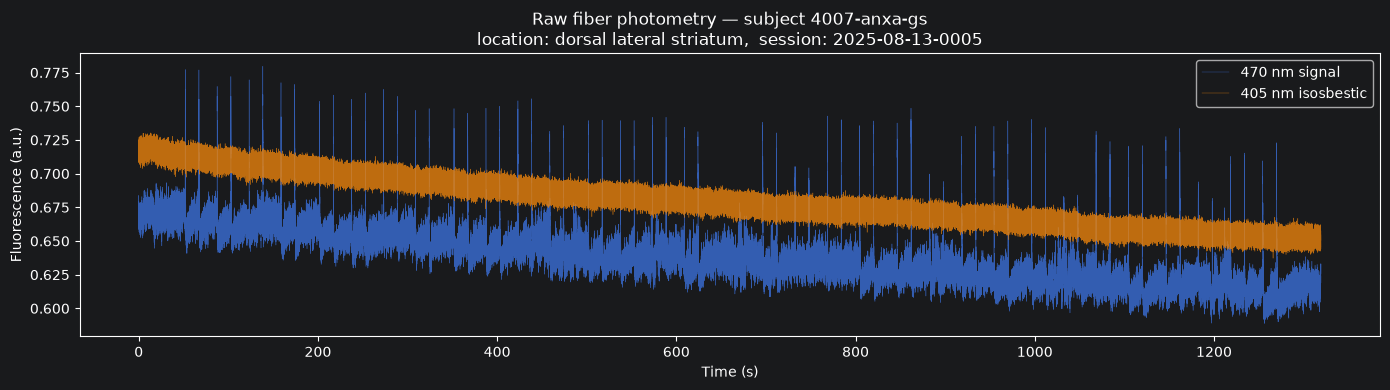

In [4]:
def get_time_vector(ts):
    """Return a time vector for a TimeSeries using timestamps or rate + starting_time."""
    n = ts.data.shape[0]
    if ts.timestamps is not None:
        return ts.timestamps[:]
    return ts.starting_time + np.arange(n) / ts.rate


raw_470 = nwb.acquisition["FiberPhotometryResponseSeriesRawSignal"]
raw_405 = nwb.acquisition["FiberPhotometryResponseSeriesIsosbesticControl"]

t_470 = get_time_vector(raw_470)
t_405 = get_time_vector(raw_405)
raw_470_arr = raw_470.data[:]  # load into memory once
raw_405_arr = raw_405.data[:]

epochs_df = nwb.intervals["OptogeneticEpochsTable"].to_dataframe()

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(t_470, raw_470_arr, color="#3A6FD8", lw=0.3, alpha=0.8, label="470 nm signal")
ax.plot(t_405, raw_405_arr, color="#E8820C", lw=0.3, alpha=0.8, label="405 nm isosbestic")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Fluorescence (a.u.)")
ax.set_title(
    f"Raw fiber photometry — subject {sub.subject_id}\n"
    f"location: dorsal lateral striatum,  session: {nwb.session_id}"
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

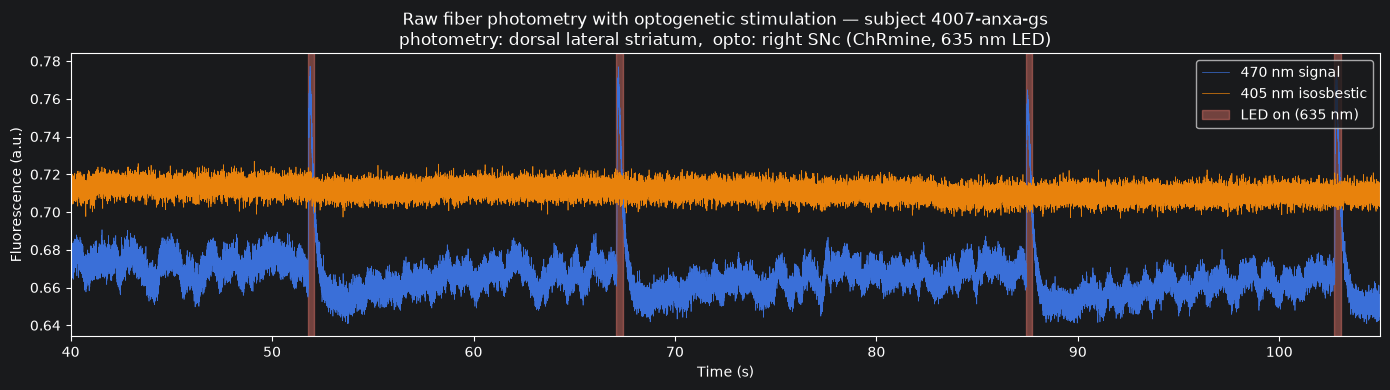

In [5]:
# Zoomed on first few stimulation epochs
T0, T1 = 40.0, 105.0

fig, ax = plt.subplots(figsize=(14, 4))
m470 = (t_470 >= T0) & (t_470 <= T1)
m405 = (t_405 >= T0) & (t_405 <= T1)
ax.plot(t_470[m470], raw_470_arr[m470], color="#3A6FD8", lw=0.5, label="470 nm signal")
ax.plot(t_405[m405], raw_405_arr[m405], color="#E8820C", lw=0.5, label="405 nm isosbestic")
first = True
for _, row in epochs_df[(epochs_df.start_time >= T0) & (epochs_df.start_time <= T1)].iterrows():
    ax.axvspan(row.start_time, row.stop_time, color="salmon", alpha=0.4, zorder=0,
               label="LED on (635 nm)" if first else None)
    first = False
ax.set_xlim(T0, T1)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Fluorescence (a.u.)")
ax.set_title(
    f"Raw fiber photometry with optogenetic stimulation — subject {sub.subject_id}\n"
    f"photometry: dorsal lateral striatum,  opto: right SNc (ChRmine, 635 nm LED)"
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 4. CommandedVoltageSeries — LED switching square wave

The `fxn_gen` ABF channel records the function generator square wave that drives the two LEDs.
It is stored as a `CommandedVoltageSeries` in `nwb.acquisition` and **linked to all four rows of
the `FiberPhotometryTable`** via the `commanded_voltage_series` column — providing a direct pointer
from each photometry trace back to the switching waveform used for demultiplexing.

| Voltage level | Meaning | Demultiplexed stream |
|---------------|---------|----------------------|
| High (> 1 V) | 470 nm LED on | `FiberPhotometryResponseSeriesRawSignal` |
| Low (< 1 V) | 405 nm LED on | `FiberPhotometryResponseSeriesIsosbesticControl` |

- **Waveform frequency** (`frequency`): 100 Hz — the LED alternation rate (10 ms per cycle).
- **Sampling rate** (`rate`): 2000 Hz — the ABF ADC rate at which the waveform is digitised.

Transition samples at each LED switch edge are discarded before storing the demultiplexed
fluorescence series, explaining why the raw signal timestamps are irregular.

CommandedVoltageSeries: 2,638,592 samples at 2000 Hz
  frequency: 100 Hz  |  unit: V
  starting_time: 0.000 s

Linked from 4 FiberPhotometryTable rows via 'commanded_voltage_series' column:
  row 0: location=dorsal lateral striatum, excitation=470 nm → 'CommandedVoltageSeries'
  row 1: location=dorsal lateral striatum, excitation=405 nm → 'CommandedVoltageSeries'
  row 2: location=dorsal medial striatum, excitation=470 nm → 'CommandedVoltageSeries'
  row 3: location=dorsal medial striatum, excitation=405 nm → 'CommandedVoltageSeries'


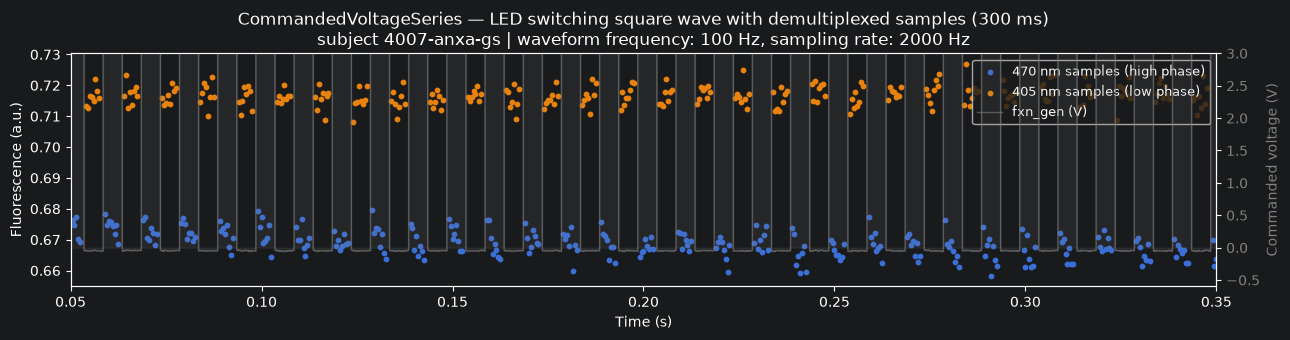

In [6]:
cvs = nwb.acquisition["CommandedVoltageSeries"]
print(f"CommandedVoltageSeries: {len(cvs.data):,} samples at {cvs.rate:.0f} Hz")
print(f"  frequency: {cvs.frequency:.0f} Hz  |  unit: {cvs.unit}")
print(f"  starting_time: {cvs.starting_time:.3f} s")

# Verify linkage to FiberPhotometryTable
fp_table_cvs = nwb.lab_meta_data["fiber_photometry"].fiber_photometry_table
df_fp = fp_table_cvs.to_dataframe()
print(f"\nLinked from {len(df_fp)} FiberPhotometryTable rows via 'commanded_voltage_series' column:")
for i in range(len(df_fp)):
    cvs_ref = fp_table_cvs["commanded_voltage_series"][i]
    print(f"  row {i}: location={fp_table_cvs['location'][i]}, "
          f"excitation={fp_table_cvs['excitation_wavelength_in_nm'][i]:.0f} nm "
          f"\u2192 '{cvs_ref.name}'")

# Load data into memory to avoid h5py boolean-indexing limitations
cvs_arr = np.asarray(cvs.data)
t_cvs = (cvs.starting_time or 0.0) + np.arange(len(cvs_arr)) / cvs.rate

# 300 ms window — enough to see ~30 LED cycles clearly
T0_cvs = t_470[0] + 0.05
T1_cvs = T0_cvs + 0.30
mc    = (t_cvs >= T0_cvs) & (t_cvs <= T1_cvs)
m470c = (t_470 >= T0_cvs) & (t_470 <= T1_cvs)
m405c = (t_405 >= T0_cvs) & (t_405 <= T1_cvs)

fig, ax = plt.subplots(figsize=(13, 3.5))
ax2 = ax.twinx()
ax2.fill_between(t_cvs[mc], cvs_arr[mc], step="post", alpha=0.12, color="gray")
ax2.plot(t_cvs[mc], cvs_arr[mc], color="gray", lw=1.0, drawstyle="steps-post",
         label="fxn_gen (V)", alpha=0.6)
ax2.set_ylabel("Commanded voltage (V)", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
ax2.set_ylim(-0.6, 3.0)

ax.scatter(t_470[m470c], raw_470_arr[m470c], color="#3A6FD8", s=10, zorder=3,
           label="470 nm samples (high phase)")
ax.scatter(t_405[m405c], raw_405_arr[m405c], color="#E8820C", s=10, zorder=3,
           label="405 nm samples (low phase)")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Fluorescence (a.u.)")
ax.set_xlim(T0_cvs, T1_cvs)
ax.set_title(
    f"CommandedVoltageSeries — LED switching square wave with demultiplexed samples (300 ms)\n"
    f"subject {sub.subject_id} | waveform frequency: {cvs.frequency:.0f} Hz, "
    f"sampling rate: {cvs.rate:.0f} Hz"
)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=9)
plt.tight_layout()
plt.show()

## 5. Raw treadmill voltage (data provenance)

The ABF `treadmill` channel is stored as `RawTreadmillVoltage` in `nwb.acquisition`
(~1.2–2.0 V, 2000 Hz). The bottom panel shows the derived velocity from
`nwb.processing['behavior']` for comparison.

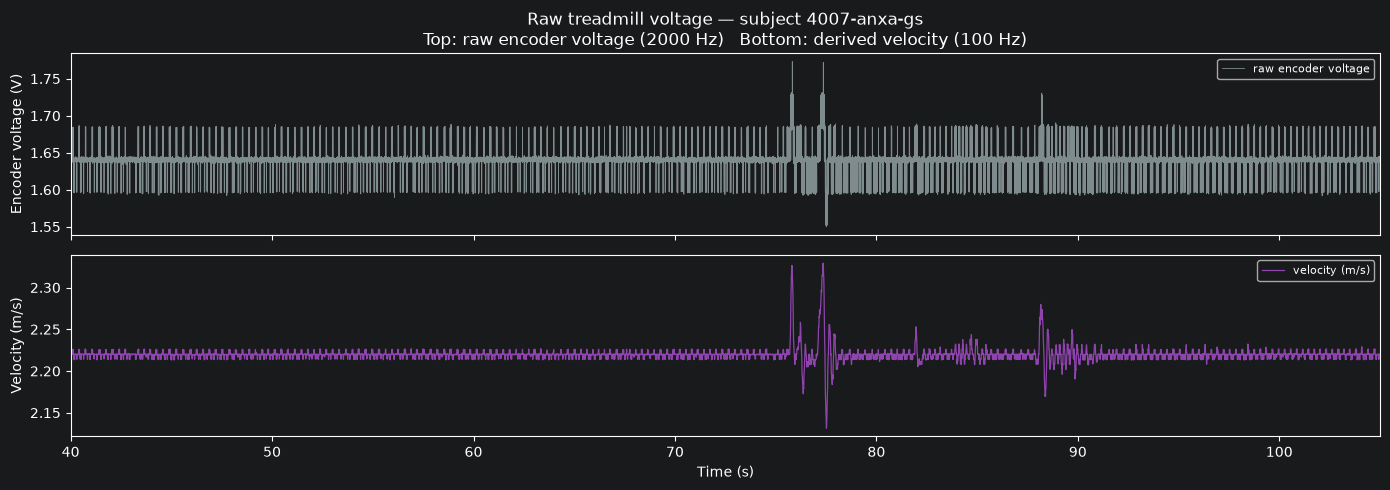

In [7]:
ts_tread = nwb.acquisition["RawTreadmillVoltage"]
t_tread  = ts_tread.timestamps[:]
v_tread  = ts_tread.data[:]

bts   = nwb.processing["behavior"]["BehavioralTimeSeries"]
vel   = bts.time_series["treadmill_velocity"]
t_beh = get_time_vector(vel)

T0, T1 = 40.0, 105.0
mt = (t_tread >= T0) & (t_tread <= T1)
mv = (t_beh   >= T0) & (t_beh   <= T1)

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)

ax_top.plot(t_tread[mt], v_tread[mt], color="#7F8C8D", lw=0.6, label="raw encoder voltage")
ax_top.set_ylabel("Encoder voltage (V)")
ax_top.set_title(
    f"Raw treadmill voltage — subject {sub.subject_id}\n"
    "Top: raw encoder voltage (2000 Hz)   Bottom: derived velocity (100 Hz)"
)
ax_top.legend(loc="upper right", fontsize=8)

ax_bot.plot(t_beh[mv], vel.data[mv], color="#8E44AD", lw=0.9, label="velocity (m/s)")
ax_bot.set_ylabel(f"Velocity ({vel.unit})")
ax_bot.set_xlabel("Time (s)")
ax_bot.set_xlim(T0, T1)
ax_bot.legend(loc="upper right", fontsize=8)

plt.tight_layout()
plt.show()

## 6. Processed fiber photometry (corrected traces and ΔF/F)

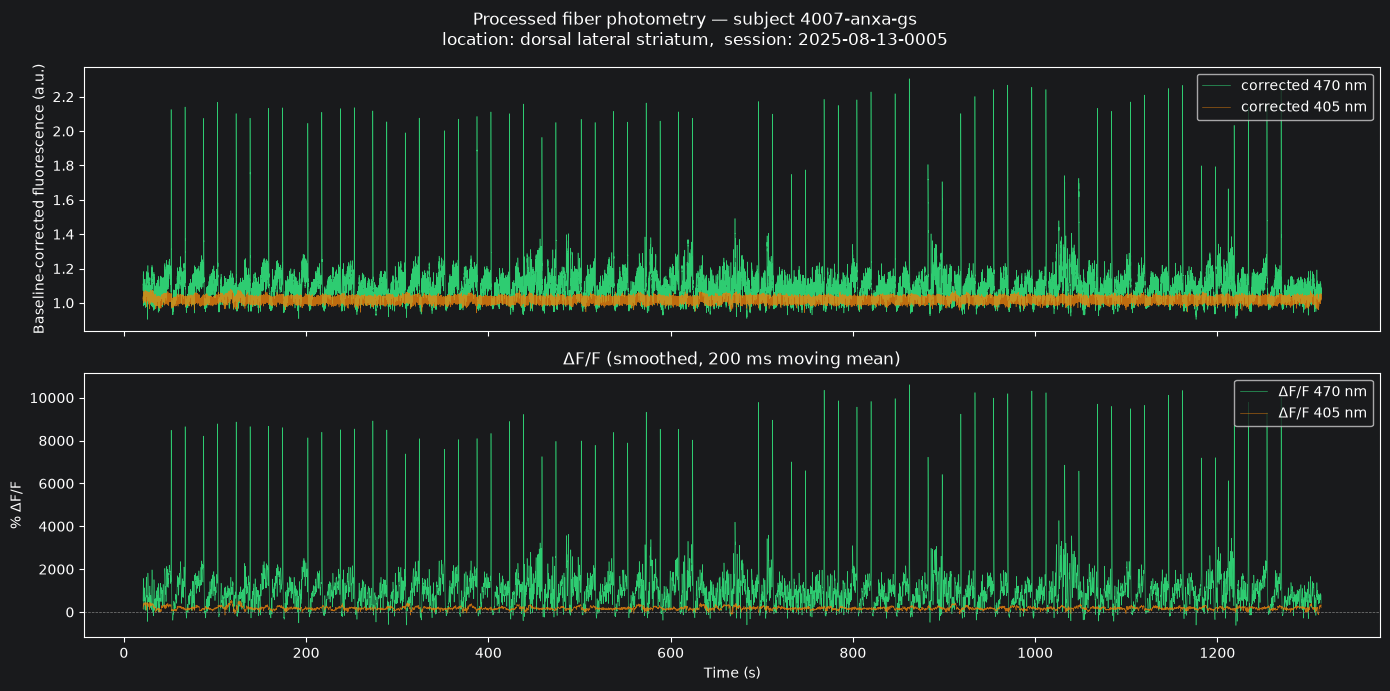

In [8]:
corr_470 = nwb.processing["ophys"]["FiberPhotometryResponseSeriesCorrectedSignal"]
corr_405 = nwb.processing["ophys"]["FiberPhotometryResponseSeriesCorrectedIsosbesticControl"]
dff_470  = nwb.processing["ophys"]["FiberPhotometryResponseSeriesDfOverF"]
dff_405  = nwb.processing["ophys"]["FiberPhotometryResponseSeriesDfOverFIsosbesticControl"]

t_proc = get_time_vector(corr_470)

SMOOTH_N = 20  # 200 ms moving mean at 100 Hz
def smooth(x, n=SMOOTH_N):
    return np.convolve(x, np.ones(n) / n, mode="same")


fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

ax1.plot(t_proc, corr_470.data[:], color="#2ECC71", lw=0.4, label="corrected 470 nm")
ax1.plot(t_proc, corr_405.data[:], color="#E8820C", lw=0.4, alpha=0.8, label="corrected 405 nm")
ax1.set_ylabel("Baseline-corrected fluorescence (a.u.)")
ax1.legend(loc="upper right")

ax2.set_title("\u0394F/F (smoothed, 200 ms moving mean)")
ax2.plot(t_proc, smooth(dff_470.data[:] * 100), color="#2ECC71", lw=0.4, label="\u0394F/F 470 nm")
ax2.plot(t_proc, smooth(dff_405.data[:] * 100), color="#E8820C", lw=0.4, alpha=0.8, label="\u0394F/F 405 nm")
ax2.axhline(0, color="gray", lw=0.5, ls="--")
ax2.set_ylabel("% \u0394F/F")
ax2.set_xlabel("Time (s)")
ax2.legend(loc="upper right")

fig.suptitle(
    f"Processed fiber photometry — subject {sub.subject_id}\n"
    f"location: dorsal lateral striatum,  session: {nwb.session_id}"
)
plt.tight_layout()
plt.show()

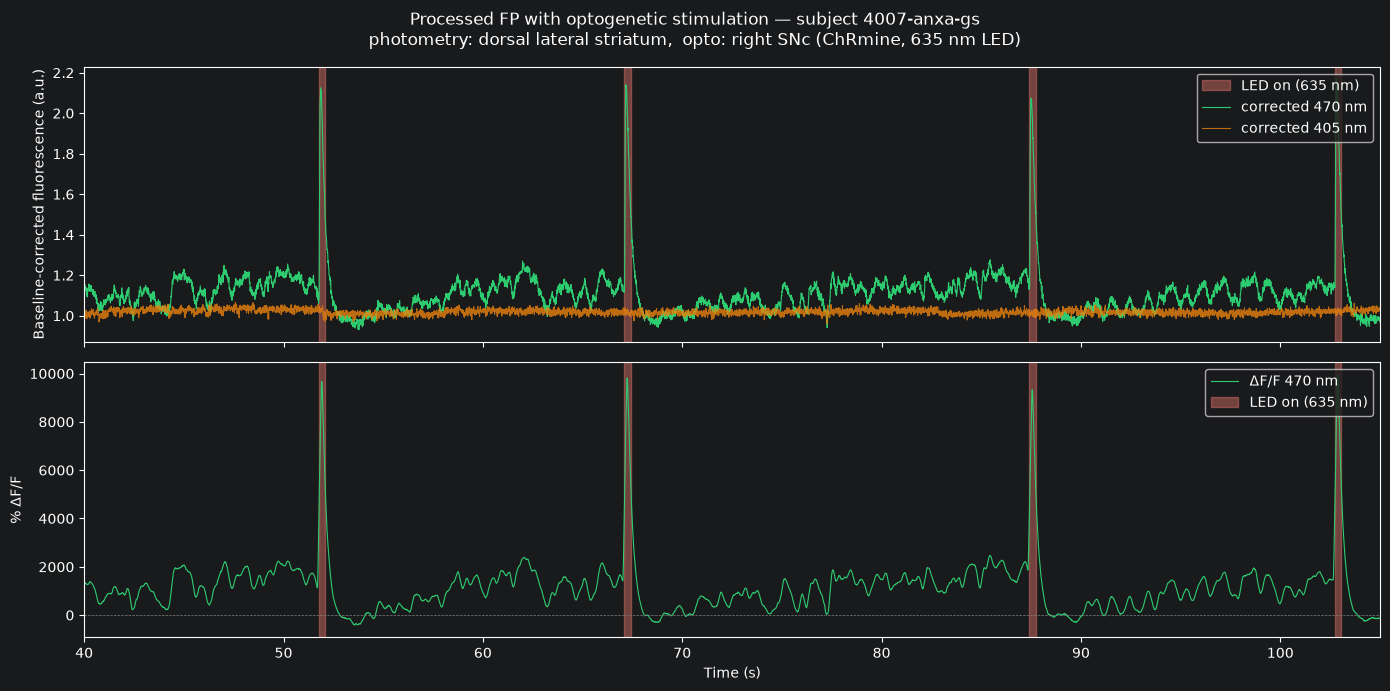

In [9]:
# Zoomed on first few stim epochs — corrected traces + ΔF/F
T0, T1 = 40.0, 105.0
mp = (t_proc >= T0) & (t_proc <= T1)
epochs_zoom = epochs_df[(epochs_df.start_time >= T0) & (epochs_df.start_time <= T1)]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
first = True
for _, row in epochs_zoom.iterrows():
    lbl = "LED on (635 nm)" if first else None
    ax1.axvspan(row.start_time, row.stop_time, color="salmon", alpha=0.4, zorder=0, label=lbl)
    ax2.axvspan(row.start_time, row.stop_time, color="salmon", alpha=0.4, zorder=0)
    first = False

ax1.plot(t_proc[mp], corr_470.data[mp], color="#2ECC71", lw=0.8, label="corrected 470 nm")
ax1.plot(t_proc[mp], corr_405.data[mp], color="#E8820C", lw=0.8, alpha=0.8, label="corrected 405 nm")
ax1.set_ylabel("Baseline-corrected fluorescence (a.u.)")
ax1.legend(loc="upper right")

ax2.plot(t_proc[mp], dff_470.data[mp] * 100, color="#2ECC71", lw=0.8, label="\u0394F/F 470 nm")
ax2.axhline(0, color="gray", lw=0.5, ls="--")
ax2.fill_between([], [], color="salmon", alpha=0.4, label="LED on (635 nm)")
ax2.set_ylabel("% \u0394F/F")
ax2.set_xlabel("Time (s)")
ax2.set_xlim(T0, T1)
ax2.legend(loc="upper right")

fig.suptitle(
    f"Processed FP with optogenetic stimulation — subject {sub.subject_id}\n"
    f"photometry: dorsal lateral striatum,  opto: right SNc (ChRmine, 635 nm LED)"
)
plt.tight_layout()
plt.show()

## 7. ΔF/F aligned to a single stimulation onset

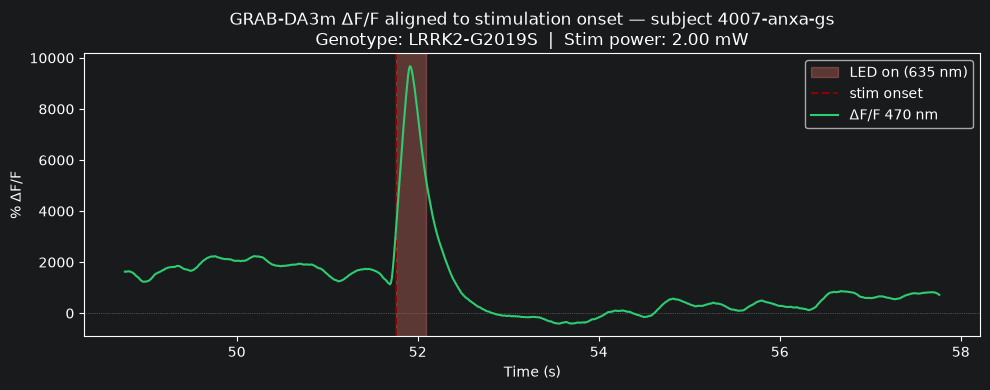

In [10]:
first_stim = epochs_df.iloc[0]
PRE, POST = 3.0, 6.0
t0 = first_stim.start_time
me = (t_proc >= t0 - PRE) & (t_proc <= t0 + POST)

power_label = (
    f"{first_stim.power_in_mW:.2f} mW"
    if not np.isnan(first_stim.power_in_mW)
    else "power N/A"
)

fig, ax = plt.subplots(figsize=(10, 4))
ax.axvspan(first_stim.start_time, first_stim.stop_time, color="salmon", alpha=0.3, zorder=0, label="LED on (635 nm)")
ax.axvline(first_stim.start_time, color="darkred", lw=1.5, ls="--", label="stim onset")
ax.axhline(0, color="gray", lw=0.5, ls=":")
ax.plot(t_proc[me], dff_470.data[me] * 100, color="#2ECC71", lw=1.5, label="\u0394F/F 470 nm")
ax.set_xlabel("Time (s)")
ax.set_ylabel("% \u0394F/F")
ax.set_title(
    f"GRAB-DA3m \u0394F/F aligned to stimulation onset — subject {sub.subject_id}\n"
    f"Genotype: {sub.genotype}  |  Stim power: {power_label}"
)
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 8. Treadmill behavior

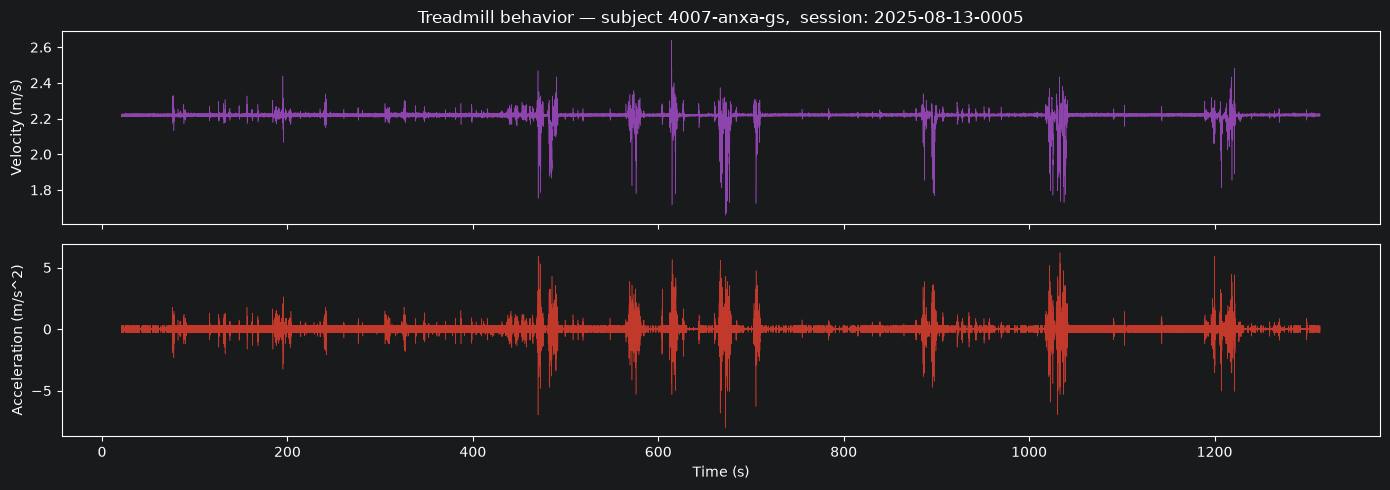

In [11]:
bts = nwb.processing["behavior"]["BehavioralTimeSeries"]
vel = bts.time_series["treadmill_velocity"]
acc = bts.time_series["treadmill_acceleration"]
t_beh = get_time_vector(vel)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 5), sharex=True)
ax1.plot(t_beh, vel.data[:], color="#8E44AD", lw=0.4)
ax1.set_ylabel(f"Velocity ({vel.unit})")
ax1.set_title(f"Treadmill behavior — subject {sub.subject_id},  session: {nwb.session_id}")

ax2.plot(t_beh, acc.data[:], color="#C0392B", lw=0.4)
ax2.set_ylabel(f"Acceleration ({acc.unit})")
ax2.set_xlabel("Time (s)")

plt.tight_layout()
plt.show()

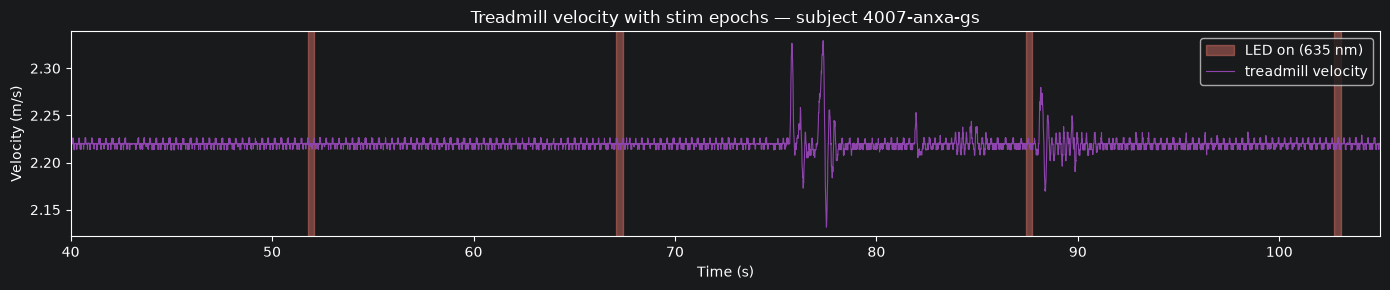

In [12]:
# Velocity zoomed with stim epochs
T0, T1 = 40.0, 105.0
mb = (t_beh >= T0) & (t_beh <= T1)
epochs_zoom = epochs_df[(epochs_df.start_time >= T0) & (epochs_df.start_time <= T1)]

fig, ax = plt.subplots(figsize=(14, 3))
first = True
for _, row in epochs_zoom.iterrows():
    ax.axvspan(row.start_time, row.stop_time, color="salmon", alpha=0.4, zorder=0,
               label="LED on (635 nm)" if first else None)
    first = False
ax.plot(t_beh[mb], vel.data[mb], color="#8E44AD", lw=0.8, label="treadmill velocity")
ax.set_xlim(T0, T1)
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"Velocity ({vel.unit})")
ax.set_title(f"Treadmill velocity with stim epochs — subject {sub.subject_id}")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

## 9. Optogenetic epochs table

Each row is one stimulation epoch. The `power_in_mW` column holds the per-epoch stimulation power
drawn from the pseudorandom sequence defined in `stimulation sequence LRRK2.xlsx`.
The `ExcitationSource` device stores the peak power; the full range and per-epoch values are here.

In [13]:
print(f"OptogeneticEpochsTable: {len(epochs_df)} rows")
print(f"Columns: {list(epochs_df.columns)}")
print()
display_cols = ["start_time", "stop_time", "power_in_mW", "pulse_length_in_ms",
                "period_in_ms", "number_pulses_per_pulse_train", "wavelength_in_nm"]
print("ExcitationSource device description:")
print(nwb.devices["led_635nm"].description)

OptogeneticEpochsTable: 64 rows
Columns: ['start_time', 'stop_time', 'stimulation_on', 'pulse_length_in_ms', 'period_in_ms', 'number_pulses_per_pulse_train', 'number_trains', 'intertrain_interval_in_ms', 'power_in_mW', 'wavelength_in_nm', 'optogenetic_sites']

ExcitationSource device description:
635 nm red LED (LEDFRJ_635, Doric Lenses) for Cre-dependent ChRmine optogenetic activation of SNc dopamine neurons (right hemisphere). Coupled via fiber-optic patch cord to the implanted 400 µm fiber cannula. Frequency, power, and duration controlled by Doric Studio software with stimulation trains triggered by a custom LabVIEW script. Power varied pseudo-randomly across epochs [0.1, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0] mW; power_in_W reflects the peak power (4.0 mW). Per-epoch power is recorded in the OptogeneticEpochsTable.


In [14]:
epochs_df[display_cols][:]

,start_time,stop_time,power_in_mW,pulse_length_in_ms,period_in_ms,number_pulses_per_pulse_train,wavelength_in_nm
id,,,,,,,
0,51.7635,52.0935,2.00,9.0,10.0,32,635.0
1,67.0900,67.4200,2.00,9.0,10.0,32,635.0
2,87.4055,87.7355,3.00,9.0,10.0,32,635.0
3,102.7320,103.0620,3.00,9.0,10.0,32,635.0
4,123.0475,123.3770,0.25,9.0,10.0,32,635.0
...,...,...,...,...,...,...,...
59,1197.7800,1198.2700,0.10,8.0,16.0,32,635.0
60,1218.2750,1218.7850,0.50,8.0,16.0,32,635.0
61,1233.7815,1234.3015,0.50,8.0,16.0,32,635.0


In [15]:
# Power level counts (epochs with defined power)
valid_epochs = epochs_df.dropna(subset=["power_in_mW"]).copy()
print(f"Epochs with defined power: {len(valid_epochs)} / {len(epochs_df)}")
print()
counts = valid_epochs["power_in_mW"].value_counts().sort_index()
print("Power (mW)   Count")
for pwr, cnt in counts.items():
    print(f"  {pwr:5.2f}      {cnt}")

Epochs with defined power: 64 / 64

Power (mW)   Count
   0.10      8
   0.25      8
   0.50      8
   1.00      8
   1.50      8
   2.00      8
   3.00      8
   4.00      8


### Full-session epoch map: stimulation power over time


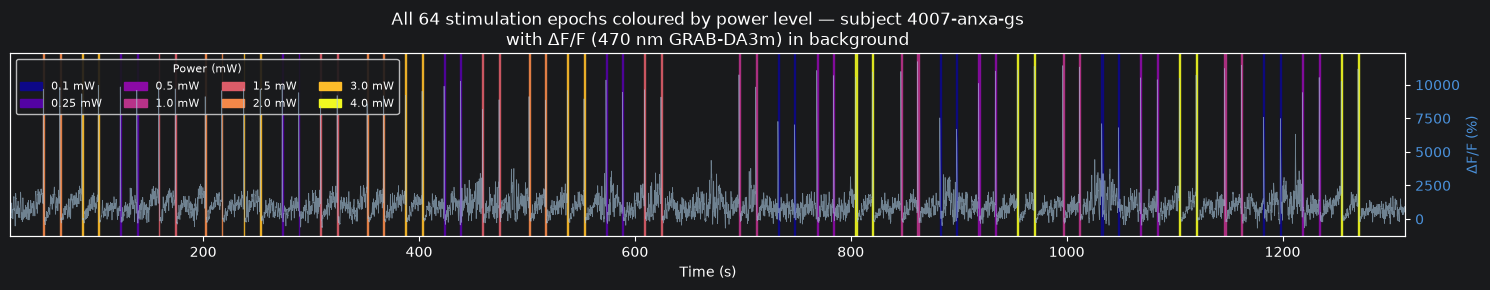

In [16]:
POWERS_LIST = [0.1, 0.25, 0.5, 1.0, 1.5, 2.0, 3.0, 4.0]
cmap_pow   = plt.colormaps["plasma"].resampled(len(POWERS_LIST))
pow_to_col = {p: cmap_pow(i) for i, p in enumerate(POWERS_LIST)}

t_dff    = dff_470.timestamps[:]
dff_full = dff_470.data[:] * 100  # % ΔF/F

fig, ax = plt.subplots(figsize=(15, 3))

ax2 = ax.twinx()
ax2.plot(t_dff, dff_full, color="#aac8e0", lw=0.5, alpha=0.6, zorder=1, label="\u0394F/F 470 nm")
ax2.set_ylabel("\u0394F/F (%)", color="#4a90d9")
ax2.tick_params(axis="y", labelcolor="#4a90d9")

for _, row in valid_epochs.iterrows():
    ax.axvspan(row.start_time, row.stop_time + 0.5,
               color=pow_to_col.get(row.power_in_mW, "gray"), alpha=0.85, zorder=2)

legend_patches = [mpatches.Patch(color=pow_to_col[p], label=f"{p} mW") for p in POWERS_LIST]
ax.legend(handles=legend_patches, title="Power (mW)", fontsize=8,
          title_fontsize=8, loc="upper left", ncol=4, framealpha=0.9)

ax.set_xlim(t_dff[0], t_dff[-1])
ax.set_ylim(0, 1)
ax.set_yticks([])
ax.set_xlabel("Time (s)")
ax.set_title(
    f"All {len(valid_epochs)} stimulation epochs coloured by power level — subject {sub.subject_id}\n"
    "with \u0394F/F (470 nm GRAB-DA3m) in background"
)
plt.tight_layout()
plt.show()

## 10. ABF Events — individual optogenetic pulses

The raw ABF `opto_TTL` channel is read at 2 kHz and each TTL-high pulse is stored as an
interval event in `nwbfile.events["OptoTTL"]`. This complements the train-level
`OptogeneticEpochsTable` with pulse-level resolution:

| Epoch range | Pulse ON | Period | Pulses/train |
|-------------|----------|--------|--------------|
| 0 – 31 (trains 1–32) | 9 ms | 10 ms | 32 |
| 32 – 63 (trains 33–64) | 8 ms | 16 ms | 32 |

The 0.01 V threshold catches both amplitude groups from the TTL channel.

OptoPulse: 2,048 interval events
  t[0]=51.772s  t[-1]=1270.310s
  duration (trains 1-32,  expected 9 ms): 9.04 ± 0.128 ms
  duration (trains 33-64, expected 8 ms): 8.01 ± 0.148 ms


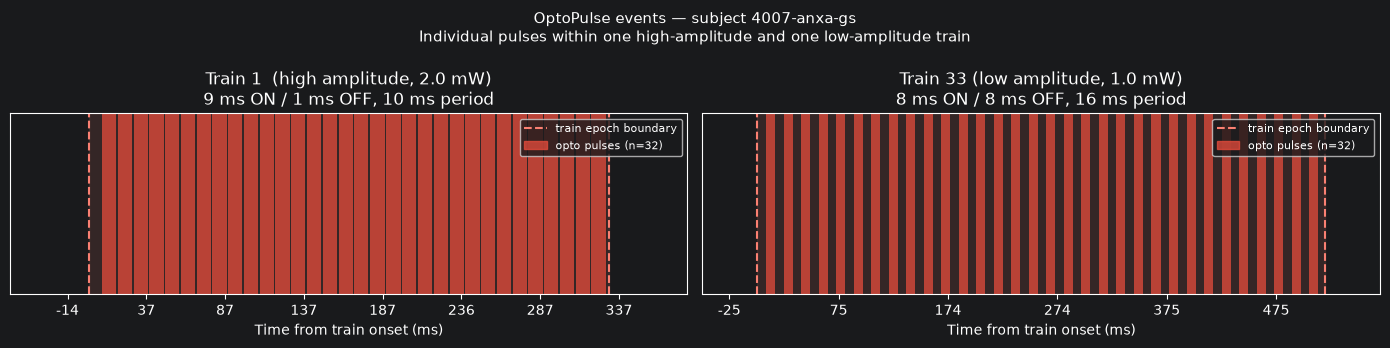

In [17]:
# Load OptoPulse events table
opto_ev = nwb.events["OptoTTL"].to_dataframe()

dur_ms = opto_ev.duration.values * 1000
print(f"OptoPulse: {len(opto_ev):,} interval events")
print(f"  t[0]={opto_ev.timestamp.iloc[0]:.3f}s  t[-1]={opto_ev.timestamp.iloc[-1]:.3f}s")
print(f"  duration (trains 1-32,  expected 9 ms): {dur_ms[:32*32].mean():.2f} \u00b1 {dur_ms[:32*32].std():.3f} ms")
print(f"  duration (trains 33-64, expected 8 ms): {dur_ms[32*32:].mean():.2f} \u00b1 {dur_ms[32*32:].std():.3f} ms")

# ── figure: two train zooms side by side ───────────────────────────────────────
fig, (ax_hi, ax_lo) = plt.subplots(1, 2, figsize=(14, 3.5), sharey=True)

def plot_train_zoom(ax, train_row, pulse_df, title):
    """Show individual pulses within one train; x-axis in ms from train onset."""
    t0 = train_row.start_time - 0.05
    t1 = train_row.stop_time  + 0.05
    pulses = pulse_df[
        (pulse_df.timestamp >= t0 - 0.01) &
        (pulse_df.timestamp <= t1 + 0.2)
    ]
    for _, p in pulses.iterrows():
        ax.axvspan(p.timestamp, p.timestamp + p.duration,
                   color="#E74C3C", alpha=0.75, zorder=2, lw=0)
    ax.axvspan(train_row.start_time, train_row.stop_time,
               color="salmon", alpha=0.12, zorder=1)
    ax.axvline(train_row.start_time, color="salmon", lw=1.5, ls="--",
               label="train epoch boundary")
    ax.axvline(train_row.stop_time,  color="salmon", lw=1.5, ls="--")
    ax.fill_between([], [], color="#E74C3C", alpha=0.75,
                    label=f"opto pulses (n={len(pulses)})")
    t_ref = train_row.start_time
    ax.set_xlim(t0, t1)
    ax.xaxis.set_major_formatter(
        plt.FuncFormatter(lambda x, _: f"{(x - t_ref)*1000:.0f}")
    )
    ax.set_ylim(0, 1.25)
    ax.set_yticks([])
    ax.set_xlabel("Time from train onset (ms)")
    ax.set_title(title)
    ax.legend(fontsize=8, loc="upper right")

ep = epochs_df
plot_train_zoom(
    ax_hi, ep.iloc[0], opto_ev,
    f"Train 1  (high amplitude, {ep.iloc[0].power_in_mW} mW)\n"
    "9 ms ON / 1 ms OFF, 10 ms period"
)
plot_train_zoom(
    ax_lo, ep.iloc[32], opto_ev,
    f"Train 33 (low amplitude, {ep.iloc[32].power_in_mW} mW)\n"
    "8 ms ON / 8 ms OFF, 16 ms period"
)

fig.suptitle(
    f"OptoPulse events — subject {sub.subject_id}\n"
    "Individual pulses within one high-amplitude and one low-amplitude train",
    fontsize=11
)
plt.tight_layout()
plt.show()

## 11. Optogenetics metadata (ndx-optogenetics)

Rich device and provenance metadata is stored via the
[ndx-optogenetics](https://github.com/catalystneuro/ndx-optogenetics) extension
in `lab_meta_data["optogenetic_experiment_metadata"]`.

This includes: LED model, optical fiber (implant coordinates),
viral vector (construct name, titer), and effector (ChRmine).

In [18]:
opto_meta = nwb.lab_meta_data["optogenetic_experiment_metadata"]

print(f"Stimulation software:  {opto_meta.stimulation_software}")
print()

# Sites table
sites_table = opto_meta.optogenetic_sites_table
n_sites = len(sites_table.to_dataframe())
print(f"Optogenetic sites: {n_sites} row(s)")
for i in range(n_sites):
    eff = sites_table["effector"][i]
    print(f"  row {i}: effector={eff.name}, label={eff.label}")
print()

# LED (excitation source)
led = nwb.devices["led_635nm"]
led_model = led.model
print(f"Excitation source (LED):")
print(f"  name:          {led.name}")
print(f"  manufacturer:  {led_model.manufacturer}")
print(f"  model number:  {led_model.model_number}")
print(f"  source type:   {led_model.source_type}")
print()

# Optical fiber (SNc implant)
opto_fiber = nwb.devices["optical_fiber_snc"]
opto_fiber_model = opto_fiber.model
fi_opto = opto_fiber.fiber_insertion
print(f"Optical fiber (SNc, optogenetics):")
print(f"  model number:  {opto_fiber_model.model_number}  ({opto_fiber_model.manufacturer})")
print(f"  core diameter: {opto_fiber_model.core_diameter_in_um:.0f} µm")
print(f"  implant AP:    {fi_opto.insertion_position_ap_in_mm} mm")
print(f"  implant ML:    {fi_opto.insertion_position_ml_in_mm} mm")
print(f"  implant DV:    {fi_opto.insertion_position_dv_in_mm} mm  (from dura surface)")
print(f"  hemisphere:    {fi_opto.hemisphere}")
print()

# Viral vector (LabelledDict — iterate by key)
vv_dict = opto_meta.optogenetic_viruses.viral_vectors
virus = vv_dict[next(iter(vv_dict))]
print(f"Viral vector:")
print(f"  construct:     {virus.construct_name}")
print(f"  manufacturer:  {virus.manufacturer}")
print(f"  titer:         {virus.titer_in_vg_per_ml:.2e} vg/mL")
print()

# Virus injection
vi_dict = opto_meta.optogenetic_virus_injections.viral_vector_injections
inj = vi_dict[next(iter(vi_dict))]
print(f"Virus injection (SNc):")
print(f"  location:      {inj.location}")
print(f"  hemisphere:    {inj.hemisphere}")
print(f"  volume:        {inj.volume_in_uL} µL  (4 depths × 0.1 µL)")
print(f"  AP:            {inj.ap_in_mm} mm,  ML: {inj.ml_in_mm} mm,  DV: {inj.dv_in_mm} mm")

Stimulation software:  Doric Studio (Doric Lenses)

Optogenetic sites: 1 row(s)
  row 0: effector=ChRmine_right, label=ChRmine

Excitation source (LED):
  name:          led_635nm
  manufacturer:  Doric Lenses
  model number:  LEDFRJ_635
  source type:   LED

Optical fiber (SNc, optogenetics):
  model number:  MFC_400/430-0.66_4.0mm_TS3.0_C60  (Doric Lenses)
  core diameter: 400 µm
  implant AP:    -3.2 mm
  implant ML:    1.6 mm
  implant DV:    4.0 mm  (from dura surface)
  hemisphere:    right

Viral vector:
  construct:     pAAV-Ef1a-DIO-ChRmine-mScarlet-WPRE
  manufacturer:  Addgene
  titer:         2.20e+13 vg/mL

Virus injection (SNc):
  location:      substantia nigra pars compacta
  hemisphere:    right
  volume:        0.4 µL  (4 depths × 0.1 µL)
  AP:            -3.2 mm,  ML: 1.6 mm,  DV: -4.25 mm


## 12. Peri-stimulus ΔF/F (PSTH)

Average ΔF/F (470 nm) aligned to each stimulation onset, baseline-subtracted using the 2 s
pre-stimulus window. Three panels: grand average (all 64 epochs), per-power average (mean ± SEM),
and a single-trial heatmap sorted by power level.

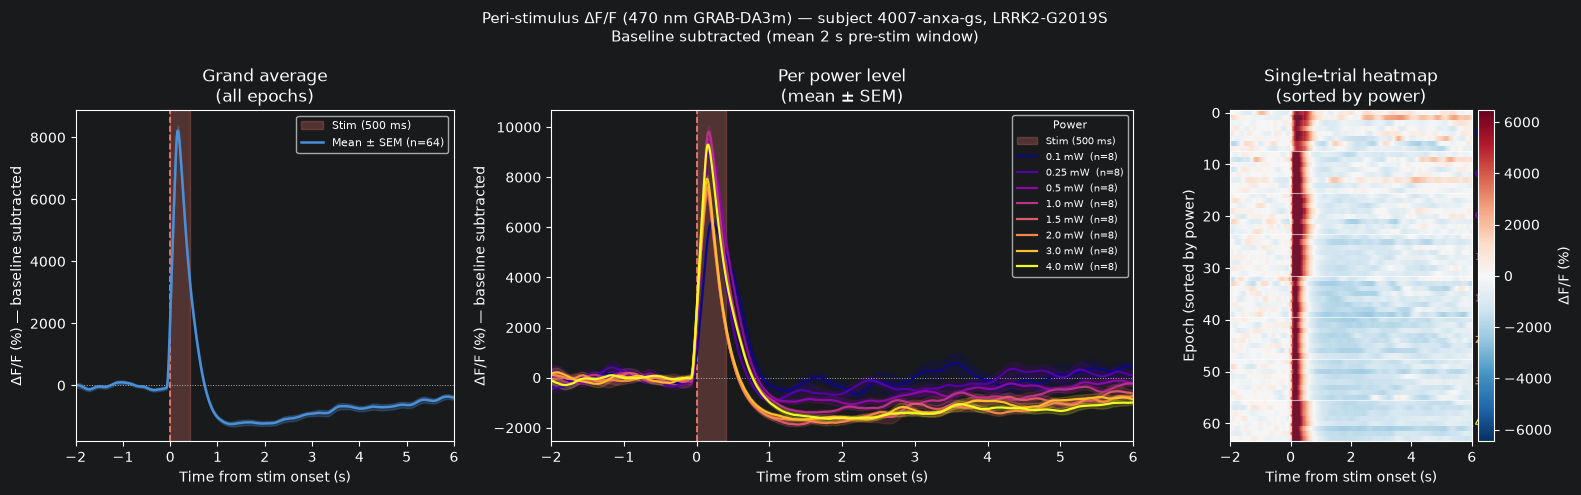

In [19]:
PRE_S, POST_S = 2.0, 6.0
dt     = np.median(np.diff(t_dff))
t_axis = np.arange(-PRE_S, POST_S + dt, dt)
STIM_DUR = np.median(valid_epochs.stop_time.values - valid_epochs.start_time.values)

snippets     = []
power_snips  = {p: [] for p in POWERS_LIST}
epoch_powers = []

for _, row in valid_epochs.iterrows():
    t_query = row.start_time + t_axis
    if t_query[0] < t_dff[0] or t_query[-1] > t_dff[-1]:
        continue
    snippet  = np.interp(t_query, t_dff, dff_full)
    baseline = snippet[t_axis < 0].mean()
    snippet -= baseline
    snippets.append(snippet)
    power_snips[row.power_in_mW].append(snippet)
    epoch_powers.append(row.power_in_mW)

snippets     = np.array(snippets)
epoch_powers = np.array(epoch_powers)

fig, axes = plt.subplots(1, 3, figsize=(16, 5),
                         gridspec_kw={"width_ratios": [1.3, 2, 1]})

def shade_stim(ax):
    ax.axvspan(0, STIM_DUR, color="salmon", alpha=0.25, label="Stim (500 ms)")
    ax.axvline(0, color="salmon", lw=1.2, ls="--")
    ax.axhline(0, color="#aaa", lw=0.7, ls=":")

# — grand average —
ax = axes[0]
shade_stim(ax)
mean_all = snippets.mean(axis=0)
sem_all  = snippets.std(axis=0) / np.sqrt(len(snippets))
ax.fill_between(t_axis, mean_all - sem_all, mean_all + sem_all, color="#4a90d9", alpha=0.25)
ax.plot(t_axis, mean_all, color="#4a90d9", lw=1.8, label=f"Mean \u00b1 SEM (n={len(snippets)})")
ax.set_xlabel("Time from stim onset (s)")
ax.set_ylabel("\u0394F/F (%) — baseline subtracted")
ax.set_title("Grand average\n(all epochs)")
ax.legend(fontsize=8)
ax.set_xlim(-PRE_S, POST_S)

# — per-power average —
ax = axes[1]
shade_stim(ax)
for p in POWERS_LIST:
    snips = np.array(power_snips[p])
    if len(snips) == 0:
        continue
    m   = snips.mean(axis=0)
    sem = snips.std(axis=0) / np.sqrt(len(snips))
    c   = pow_to_col[p]
    ax.fill_between(t_axis, m - sem, m + sem, color=c, alpha=0.18)
    ax.plot(t_axis, m, color=c, lw=1.6, label=f"{p} mW  (n={len(snips)})")
ax.set_xlabel("Time from stim onset (s)")
ax.set_ylabel("\u0394F/F (%) — baseline subtracted")
ax.set_title("Per power level\n(mean \u00b1 SEM)")
ax.legend(fontsize=7.5, loc="upper right", title="Power", title_fontsize=8)
ax.set_xlim(-PRE_S, POST_S)

# — single-trial heatmap sorted by power —
ax = axes[2]
sort_order     = np.argsort(epoch_powers)
hmap           = snippets[sort_order]
powers_sorted2 = epoch_powers[sort_order]
vmax = np.percentile(np.abs(hmap), 98)
im   = ax.imshow(hmap, aspect="auto",
                 extent=[-PRE_S, POST_S, len(hmap) - 0.5, -0.5],
                 cmap="RdBu_r", vmin=-vmax, vmax=vmax,
                 origin="upper", interpolation="nearest")
ax.axvline(0, color="white", lw=1.2, ls="--", alpha=0.7)
ax.axvspan(0, STIM_DUR, color="white", alpha=0.08)
plt.colorbar(im, ax=ax, label="\u0394F/F (%)", pad=0.02)
prev_p, prev_i = powers_sorted2[0], 0
for i, p in enumerate(powers_sorted2):
    if p != prev_p:
        ax.axhline(i - 0.5, color="white", lw=0.8, alpha=0.6)
        ax.text(POST_S + 0.1, (prev_i + i) / 2, f"{prev_p}",
                fontsize=6.5, va="center", ha="left",
                color=pow_to_col[prev_p], fontweight="bold")
        prev_p, prev_i = p, i
ax.text(POST_S + 0.1, (prev_i + len(powers_sorted2)) / 2, f"{prev_p}",
        fontsize=6.5, va="center", ha="left",
        color=pow_to_col[prev_p], fontweight="bold")
ax.set_xlabel("Time from stim onset (s)")
ax.set_ylabel("Epoch (sorted by power)")
ax.set_title("Single-trial heatmap\n(sorted by power)")
ax.set_xlim(-PRE_S, POST_S)

fig.suptitle(
    f"Peri-stimulus \u0394F/F (470 nm GRAB-DA3m) — subject {sub.subject_id}, {sub.genotype}\n"
    "Baseline subtracted (mean 2 s pre-stim window)",
    fontsize=11
)
plt.tight_layout()
plt.show()

In [20]:
nwb.read_io.close()